IMPOR LIBRARY

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
!pip install split-folders

**DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**INISIALISASI**

In [ ]:
SKENARIO = 'YCBCR' # 'RGB', 'LAB', 'YCBCR'
LEARNING_RATE = 1e-4
BATCH_SIZE = 16
EPOCHS = 25
IMG_SIZE = 224

# PATH DIRECTORY
DATASET_MENTAH = '/content/drive/MyDrive/skripsi/dataset'
FOLDER_PROSES  = f'/content/drive/MyDrive/skripsi/dataset_processed_{SKENARIO}'
FOLDER_FINAL   = f'/content/drive/MyDrive/skripsi/final_split_{SKENARIO}'

print(f"Skenario Aktif: {SKENARIO}")

Skenario Aktif: YCBCR


**Preprocessing**

In [ ]:
def run_preprocessing(src_dir, dest_dir, scenario):

    os.makedirs(dest_dir, exist_ok=True)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    print(f"\n--- PREPROCESSING {scenario} ---")

    for category in os.listdir(src_dir):

        category_path = os.path.join(src_dir, category)
        if not os.path.isdir(category_path):
            continue

        save_path = os.path.join(dest_dir, category)
        os.makedirs(save_path, exist_ok=True)

        for img_name in tqdm(os.listdir(category_path), desc=f"Kelas {category}"):

            img_path = os.path.join(category_path, img_name)
            image = cv2.imread(img_path)
            if image is None:
                continue

            img_res = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            if scenario == 'RGB':
                b, g, r = cv2.split(img_res)
                g_enhanced = clahe.apply(g)
                final_img = cv2.merge((b, g_enhanced, r))

            elif scenario == 'LAB':
                lab = cv2.cvtColor(img_res, cv2.COLOR_BGR2LAB)
                l, a, b_lab = cv2.split(lab)
                l_enhanced = clahe.apply(l)
                merged = cv2.merge((l_enhanced, a, b_lab))
                final_img = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

            elif scenario == 'YCBCR':
                ycbcr = cv2.cvtColor(img_res, cv2.COLOR_BGR2YCrCb)
                y, cb, cr = cv2.split(ycbcr)
                y_enhanced = clahe.apply(y)
                merged = cv2.merge((y_enhanced, cb, cr))
                final_img = cv2.cvtColor(merged, cv2.COLOR_YCrCb2BGR)

            cv2.imwrite(os.path.join(save_path, img_name), final_img)

    print(f"\n[SUKSES] Preprocessing selesai → {dest_dir}")

run_preprocessing(DATASET_MENTAH, FOLDER_PROSES, SKENARIO)


--- PREPROCESSING YCBCR ---


Kelas glaucoma: 100%|██████████| 1007/1007 [01:27<00:00, 11.49it/s]


[SUKSES] Preprocessing selesai → /content/drive/MyDrive/skripsi/dataset_processed_YCBCR


**Split data**

In [ ]:
import splitfolders

print(f"Membagi dataset {SKENARIO} (70% Train, 20% Val, 10% Test)...")
splitfolders.ratio(FOLDER_PROSES, output=FOLDER_FINAL, seed=42, ratio=(.7, .2, .1))
print("Splitting Berhasil!")

Membagi dataset YCBCR (70% Train, 20% Val, 10% Test)...


Copying files: 4218 files [01:09, 60.94 files/s]

Splitting Berhasil!



--- DISTRIBUSI DATASET MENTAH (YCBCR) ---
Kelas cataract: 1038 gambar
Kelas diabetic_retinopathy: 1099 gambar
Kelas glaucoma: 1007 gambar
Kelas normal: 1074 gambar
Total Seluruh Data: 4218 gambar


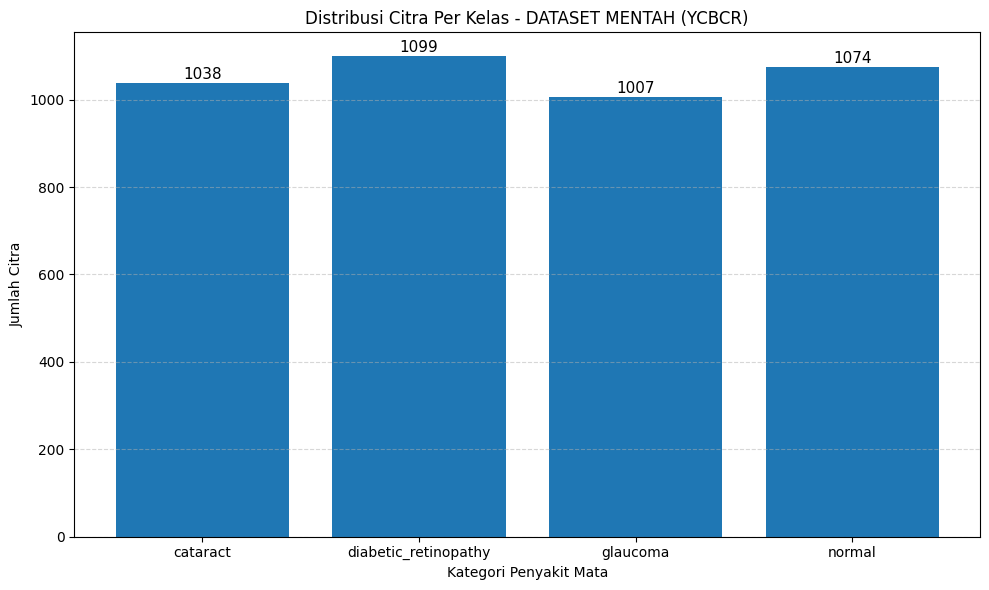


--- DISTRIBUSI DATASET PROSES (YCBCR) ---
Kelas cataract: 1038 gambar
Kelas diabetic_retinopathy: 1099 gambar
Kelas glaucoma: 1007 gambar
Kelas normal: 1074 gambar
Total Seluruh Data: 4218 gambar


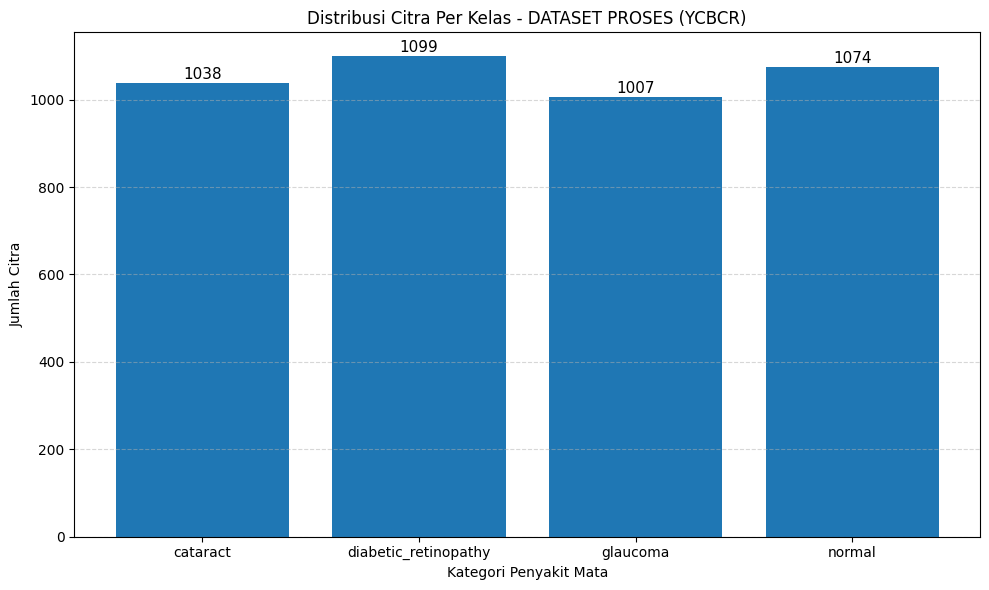


--- DISTRIBUSI TRAIN (YCBCR) ---
Kelas cataract: 726 gambar
Kelas diabetic_retinopathy: 769 gambar
Kelas glaucoma: 704 gambar
Kelas normal: 751 gambar
Total Seluruh Data: 2950 gambar


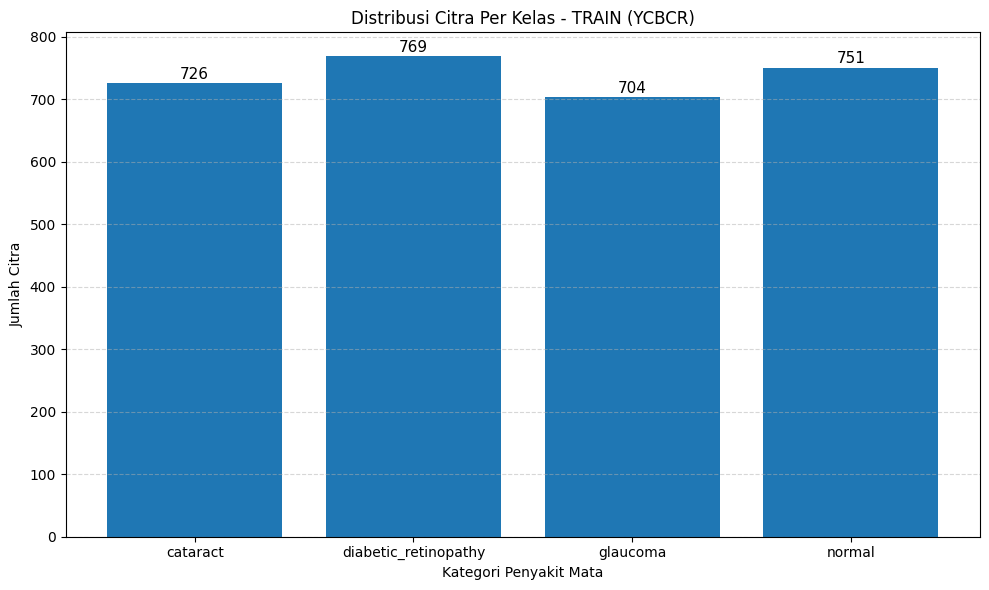


--- DISTRIBUSI VALIDATION (YCBCR) ---
Kelas cataract: 207 gambar
Kelas diabetic_retinopathy: 219 gambar
Kelas glaucoma: 201 gambar
Kelas normal: 214 gambar
Total Seluruh Data: 841 gambar


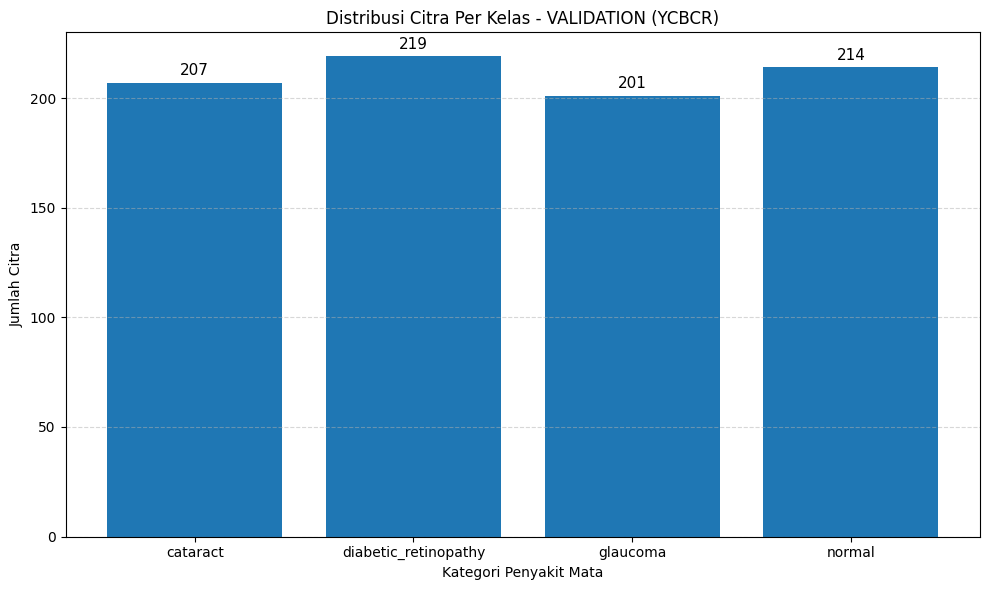


--- DISTRIBUSI TEST (YCBCR) ---
Kelas cataract: 105 gambar
Kelas diabetic_retinopathy: 111 gambar
Kelas glaucoma: 102 gambar
Kelas normal: 109 gambar
Total Seluruh Data: 427 gambar


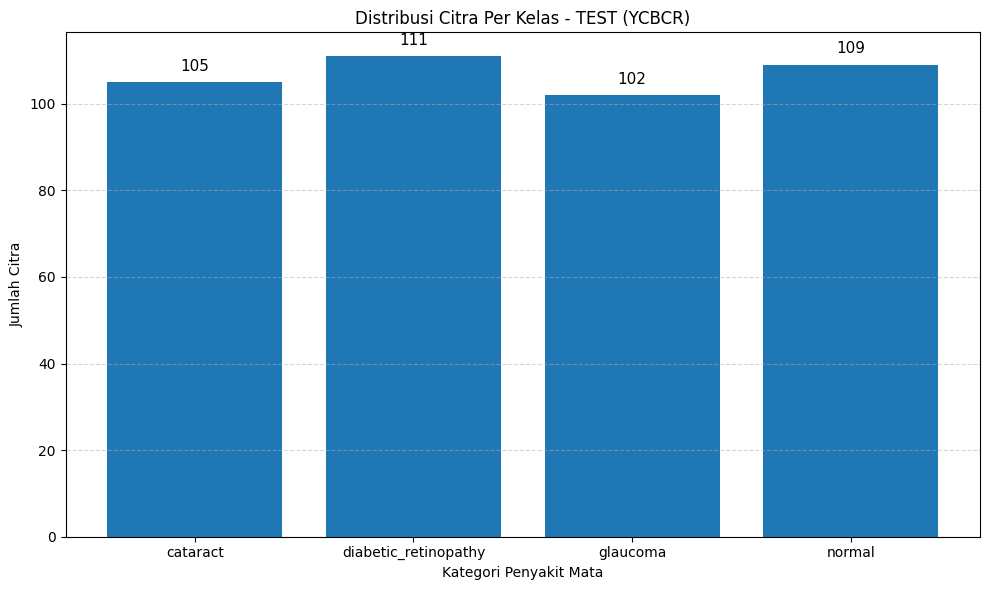

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def hitung_distribusi_dataset(path, nama_set="DATASET"):

    if not os.path.exists(path):
        print(f"[ERROR] Path tidak ditemukan: {path}")
        return

    data_hitung = []
    daftar_kelas = sorted([
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d))
    ])

    print(f"\n--- DISTRIBUSI {nama_set} ({SKENARIO}) ---")

    total_seluruh = 0
    for kelas in daftar_kelas:
        kelas_path = os.path.join(path, kelas)
        jumlah = len([
            f for f in os.listdir(kelas_path)
            if os.path.isfile(os.path.join(kelas_path, f))
        ])

        data_hitung.append({'Kelas': kelas, 'Jumlah': jumlah})
        total_seluruh += jumlah
        print(f"Kelas {kelas}: {jumlah} gambar")

    df = pd.DataFrame(data_hitung)
    print(f"Total Seluruh Data: {total_seluruh} gambar")

    # Visualisasi
    plt.figure(figsize=(10, 6))
    bars = plt.bar(df['Kelas'], df['Jumlah'])  # warna otomatis

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 yval + 2,
                 int(yval),
                 ha='center',
                 va='bottom',
                 fontsize=11)

    plt.title(f"Distribusi Citra Per Kelas - {nama_set} ({SKENARIO})")
    plt.xlabel("Kategori Penyakit Mata")
    plt.ylabel("Jumlah Citra")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# ===============================
# EKSEKUSI
# ===============================

# 1️⃣ Cek dataset mentah
hitung_distribusi_dataset(DATASET_MENTAH, "DATASET MENTAH")

# 2️⃣ Cek dataset hasil preprocessing
hitung_distribusi_dataset(FOLDER_PROSES, "DATASET PROSES")

# 3️⃣ Cek hasil split
hitung_distribusi_dataset(os.path.join(FOLDER_FINAL, "train"), "TRAIN")
hitung_distribusi_dataset(os.path.join(FOLDER_FINAL, "val"), "VALIDATION")
hitung_distribusi_dataset(os.path.join(FOLDER_FINAL, "test"), "TEST")